<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/dl/LSTM_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📋 LSTM 첫걸음
> **🎯 이 노트북은 누구를 위한 건가요?**
> - RNN 노트북을 마쳤거나 RNN 개념을 들어본 분
> - "RNN은 긴 시퀀스를 못 외운다는데, LSTM은 어떻게 해결했지?" 가 궁금한 분
> - **3개의 게이트** 가 뭔지, 왜 LSTM이 NLP에서 표준이 됐는지 알고 싶은 분

---

## 📖 오늘의 이야기 한 줄 요약

> **"중요한 건 오래 기억하고, 필요 없는 건 잊어버리는 똑똑한 RNN — LSTM."**

비유로 풀자면 — **회의실 화이트보드 정리** 같아요:

```
📋 새 정보 들어옴 → 화이트보드에 적을지 말지 결정 (Input gate)
🗑️ 오래된 정보 → 지울지 남길지 결정 (Forget gate)
📤 현재 보고할 내용 → 화이트보드에서 어떤 부분 발표 (Output gate)
```

이 **3개의 게이트** 가 LSTM의 핵심. 매 시각마다 똑똑한 판단을 내려줍니다.

## 🛠️ 준비물

| 항목 | 내용 |
|---|---|
| 환경 | Google Colab (무료) |
| 가속기 | CPU OK, GPU 있으면 더 빠름 |
| 시간 | 약 60~80분 |
| 사전 지식 | RNN 노트북 또는 RNN 기본 |

## 🗺️ 학습 로드맵

```
1️⃣ RNN의 한계 복습 — 왜 LSTM이 필요한가
2️⃣ LSTM의 아이디어 — 두 가지 메모장 (Cell state + Hidden state)
3️⃣ 3개의 게이트 (Input / Forget / Output)
4️⃣ LSTM cell 수식과 그림
5️⃣ 환경 + 데이터 (긴 시퀀스 사인파)
6️⃣ 🎯 미션 1: LSTM cell forward 직접 만들기 ✏️
7️⃣ PyTorch nn.LSTM — 한 줄!
8️⃣ 학습 + 예측 시각화
9️⃣ 🎯 미션 2: RNN vs LSTM 장기 의존성 비교 ✏️
🔟 도전 과제 + 정리
```

> **💡 학습 팁**: LSTM은 처음엔 복잡해 보여요. 게이트 3개 한 번에 외우려 하지 말고
> **"각 게이트가 어떤 비유에 해당하는지"** 만 잡으세요.


---
# 1️⃣ RNN의 한계 다시 보기

## 1.1 RNN의 문제 — 한 페이지 메모장

RNN은 매 시각 hidden state(메모장)를 **통째로 새로 갱신** 해요.

```
시각 1: 메모장 = "사과 빨갛다"
시각 50: 메모장 = "어제 마트, 사과 가격, 할인...?" (시각 1 정보 거의 없음)
시각 100: 시각 1 정보 거의 0
```

`tanh` 미분 값이 1 이하라 → 시간 누적되면 **0에 수렴 → vanishing gradient**.

## 1.2 [비유] 화이트보드 vs 메모장 📋

회의실에 두 가지 보드가 있다고 상상:

| | 메모장 (RNN) | 화이트보드 (LSTM) |
|---|---|---|
| 정보 갱신 | 매번 통째로 새로 씀 | 부분만 지우고 부분만 추가 |
| 오래된 정보 | 점점 흐려짐 | 중요하면 그대로 남음 |
| 새 정보 | 항상 추가됨 | 중요하면 추가, 아니면 패스 |
| 결과 보고 | 메모장 그대로 | 화이트보드에서 핵심만 발표 |

> 이 화이트보드가 **Cell state (장기 기억)** , 발표 부분이 **Hidden state (단기 기억)** 입니다.

## 1.3 LSTM의 핵심 아이디어 — 게이트로 정보 흐름 제어

```
새 정보 → [Input Gate] → 화이트보드에 추가할지 결정
화이트보드의 옛 정보 → [Forget Gate] → 지울지 결정
화이트보드 전체 → [Output Gate] → 어떤 부분 발표할지 결정
```

3개의 게이트가 0~1 값으로 "얼마나 통과시킬지" 정해요. **0 = 차단, 1 = 통과**.
Sigmoid 함수가 이 게이트의 활성 함수입니다.


In [1]:
# 한글 폰트
!apt-get install -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null

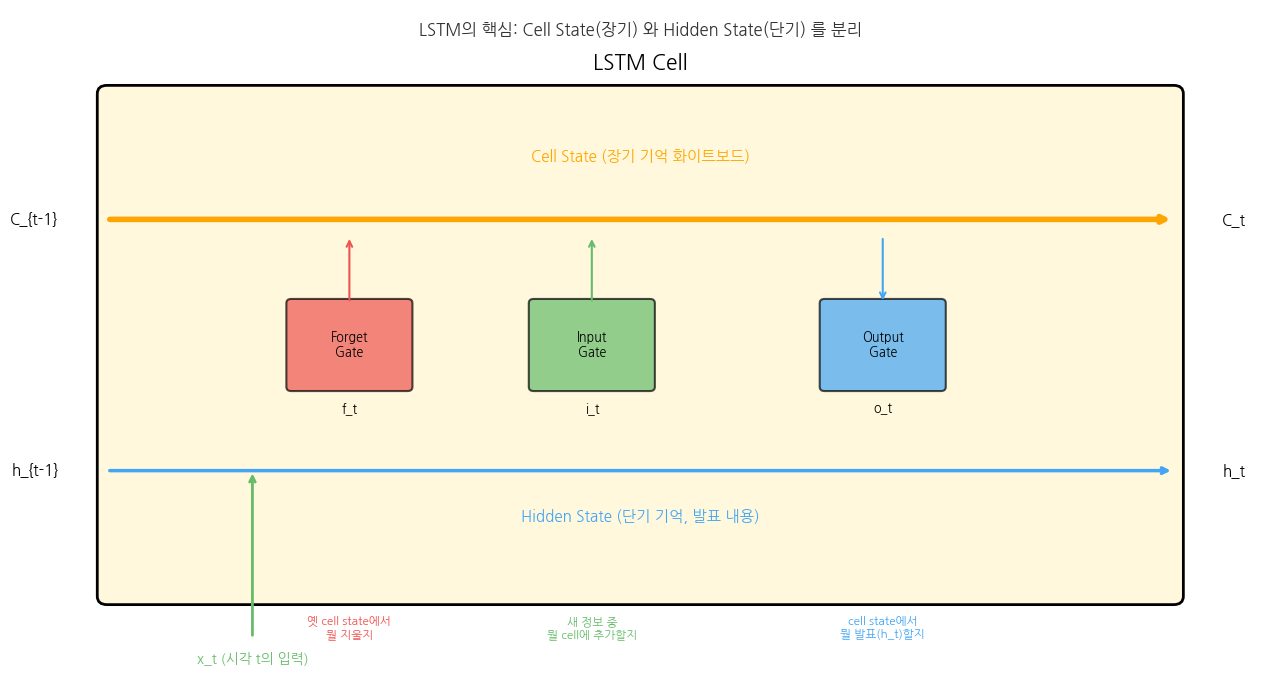


💡 한 줄 요약:
  - Cell state (C_t): '오래된 화이트보드' — 정보가 거의 그대로 흐름
  - Hidden state (h_t): '발표 내용' — Cell state에서 필요한 부분만 뽑음
  - 3개의 게이트: 정보 흐름을 0~1로 제어 (sigmoid)


In [2]:
# 🖼️ LSTM cell 구조 다이어그램

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as fm
import numpy as np
import os

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 13); ax.set_ylim(0, 8)
ax.axis("off")

# ── 외곽 LSTM cell 박스 ──
ax.add_patch(patches.FancyBboxPatch((1, 1), 11, 6,
    boxstyle="round,pad=0.1", facecolor="#FFF8DC", edgecolor="black", lw=2))
ax.text(6.5, 7.3, "LSTM Cell", ha="center", fontsize=15, fontweight="bold")

# ── Cell state 라인 (수평 — 화이트보드) ──
ax.annotate("", xy=(12, 5.5), xytext=(1, 5.5),
            arrowprops=dict(arrowstyle="->", lw=4, color="#FFA500"))
ax.text(0.5, 5.5, "C_{t-1}", ha="right", va="center", fontsize=11, fontweight="bold")
ax.text(12.5, 5.5, "C_t", ha="left", va="center", fontsize=11, fontweight="bold")
ax.text(6.5, 6.2, "Cell State (장기 기억 화이트보드)",
        ha="center", fontsize=11, color="#FFA500", fontweight="bold")

# ── Hidden state 라인 (수평 — 발표) ──
ax.annotate("", xy=(12, 2.5), xytext=(1, 2.5),
            arrowprops=dict(arrowstyle="->", lw=2.5, color="#42a5f5"))
ax.text(0.5, 2.5, "h_{t-1}", ha="right", va="center", fontsize=11, fontweight="bold")
ax.text(12.5, 2.5, "h_t", ha="left", va="center", fontsize=11, fontweight="bold")
ax.text(6.5, 1.9, "Hidden State (단기 기억, 발표 내용)",
        ha="center", fontsize=11, color="#42a5f5", fontweight="bold")

# ── 입력 ──
ax.annotate("", xy=(2.5, 2.5), xytext=(2.5, 0.5),
            arrowprops=dict(arrowstyle="->", lw=2, color="#66bb6a"))
ax.text(2.5, 0.2, "x_t (시각 t의 입력)", ha="center", fontsize=10, color="#66bb6a")

# ── 3개의 게이트 (간단한 박스로) ──
gates = [
    (3.5, 4, "Forget\nGate", "#ef5350", "f_t"),
    (6.0, 4, "Input\nGate", "#66bb6a", "i_t"),
    (9.0, 4, "Output\nGate", "#42a5f5", "o_t"),
]
for x, y, txt, color, name in gates:
    ax.add_patch(patches.FancyBboxPatch((x - 0.6, y - 0.5), 1.2, 1,
        boxstyle="round,pad=0.05", facecolor=color, edgecolor="black", lw=1.5,
        alpha=0.7))
    ax.text(x, y, txt, ha="center", va="center", fontsize=9, fontweight="bold")
    ax.text(x, y - 0.8, name, ha="center", fontsize=9, color="black")

# 게이트 → cell state로 가는 화살표
ax.annotate("", xy=(3.5, 5.3), xytext=(3.5, 4.5),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#ef5350"))
ax.annotate("", xy=(6.0, 5.3), xytext=(6.0, 4.5),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#66bb6a"))
ax.annotate("", xy=(9.0, 5.3), xytext=(9.0, 4.5),
            arrowprops=dict(arrowstyle="<-", lw=1.5, color="#42a5f5"))

# 게이트 역할 설명
ax.text(3.5, 0.5, "옛 cell state에서\n뭘 지울지", ha="center", fontsize=8.5, color="#ef5350")
ax.text(6.0, 0.5, "새 정보 중\n뭘 cell에 추가할지", ha="center", fontsize=8.5, color="#66bb6a")
ax.text(9.0, 0.5, "cell state에서\n뭘 발표(h_t)할지", ha="center", fontsize=8.5, color="#42a5f5")

ax.text(6.5, 7.7, "LSTM의 핵심: Cell State(장기) 와 Hidden State(단기) 를 분리",
        ha="center", fontsize=12, fontweight="bold", color="#333")

plt.tight_layout(); plt.show()

print("\n💡 한 줄 요약:")
print("  - Cell state (C_t): '오래된 화이트보드' — 정보가 거의 그대로 흐름")
print("  - Hidden state (h_t): '발표 내용' — Cell state에서 필요한 부분만 뽑음")
print("  - 3개의 게이트: 정보 흐름을 0~1로 제어 (sigmoid)")

---
# 2️⃣ LSTM 수식 — 한 시각 동작

> ⚠️ 처음 보면 압도되는데, 한 줄씩 비유와 함께 보면 어렵지 않아요.

## 2.1 5개 수식 (한 시각 t에서)

```
1) f_t = sigmoid(W_f · [h_{t-1}, x_t] + b_f)        ← Forget gate
2) i_t = sigmoid(W_i · [h_{t-1}, x_t] + b_i)        ← Input gate
3) g_t = tanh   (W_g · [h_{t-1}, x_t] + b_g)        ← 후보 새 정보
4) C_t = f_t * C_{t-1}  +  i_t * g_t                ← Cell state 갱신
5) o_t = sigmoid(W_o · [h_{t-1}, x_t] + b_o)        ← Output gate
   h_t = o_t * tanh(C_t)                             ← Hidden state
```

여기서 `*` 는 **원소별 곱** (element-wise), `[h, x]` 는 **연결(concatenation)** 입니다.

## 2.2 한 줄씩 비유 매핑

| 수식 | 의미 | 비유 |
|---|---|---|
| **f_t = sigmoid(...)** | 0~1, 옛 정보 유지 비율 | "화이트보드 옛 메모를 얼마나 지울까?" 0=다 지움, 1=보존 |
| **i_t = sigmoid(...)** | 0~1, 새 정보 받을 비율 | "이번 새 정보를 얼마나 추가할까?" |
| **g_t = tanh(...)** | -1~1, 후보 새 정보 | "이번 새 정보의 내용 자체" |
| **C_t = f·C + i·g** | 새 cell state | "(보존할 옛 메모) + (받아들일 새 메모)" |
| **o_t = sigmoid(...)** | 0~1, 발표 비율 | "전체 화이트보드에서 얼마를 지금 발표?" |
| **h_t = o·tanh(C)** | 새 hidden state | "Cell state를 -1~1로 압축한 뒤, output gate로 거름" |

## 2.3 [중요] sigmoid vs tanh

| 함수 | 출력 범위 | 의미 |
|---|---|---|
| **sigmoid** | 0 ~ 1 | "**얼마나 통과시킬까**" — 게이트에 사용 |
| **tanh**    | -1 ~ 1 | "**값 자체**" — 정보 내용에 사용 |

> 게이트(f, i, o)는 **0~1 비율** 이라서 sigmoid.
> 후보 정보 g와 cell→hidden 변환은 **값** 이라서 tanh.

이걸 코드로 옮기는 게 미션 1!


---
# 3️⃣ 환경 + 데이터 (긴 시퀀스로 LSTM의 강점 확인)

LSTM의 진짜 강점은 **긴 시퀀스** 에서 나옵니다. RNN 노트북에선 윈도우 20을 썼는데,
오늘은 윈도우 100으로 늘려서 차이를 봅시다.


PyTorch 2.10.0+cu128 / 디바이스 cuda


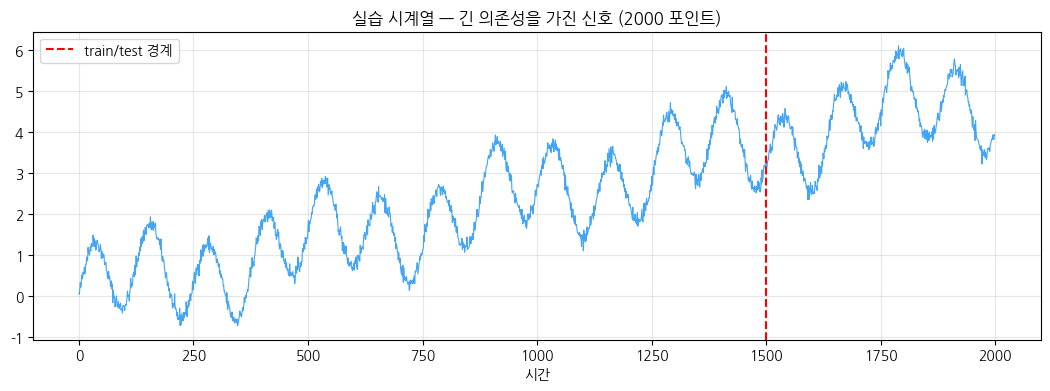

In [3]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os, sys

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

torch.manual_seed(42); np.random.seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} / 디바이스 {device}")

# 길이 2000 시계열 (RNN 노트북보다 길게)
N = 2000
t = np.linspace(0, 100, N)
# 더 복잡한 패턴 — 빠른 + 느린 주기 + 트렌드
signal = np.sin(t) + 0.5 * np.sin(0.3 * t) + 0.05 * t + 0.1 * np.random.randn(N)

plt.figure(figsize=(13, 4))
plt.plot(signal, lw=0.8, color="#42a5f5")
plt.axvline(1500, color="red", ls="--", label="train/test 경계")
plt.title("실습 시계열 — 긴 의존성을 가진 신호 (2000 포인트)")
plt.xlabel("시간"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [4]:
def make_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)


# 윈도우 100 — RNN보다 5배 긴 시퀀스!
WINDOW = 100

train_signal = signal[:1500]
test_signal  = signal[1500:]

X_train, y_train = make_sequences(train_signal, WINDOW)
X_test,  y_test  = make_sequences(test_signal,  WINDOW)

X_train_t = torch.FloatTensor(X_train).unsqueeze(-1).to(device)
y_train_t = torch.FloatTensor(y_train).unsqueeze(-1).to(device)
X_test_t  = torch.FloatTensor(X_test ).unsqueeze(-1).to(device)
y_test_t  = torch.FloatTensor(y_test ).unsqueeze(-1).to(device)

print(f"Train 샘플: {X_train_t.shape}  (배치, 시퀀스 길이 {WINDOW}, feature)")
print(f"Test  샘플: {X_test_t.shape}")
print(f"\n💡 100 시각이라는 긴 시퀀스 — 일반 RNN은 vanishing gradient로 학습 어려움!")
print(f"   LSTM이 어떻게 해내는지 봅시다.")

Train 샘플: torch.Size([1400, 100, 1])  (배치, 시퀀스 길이 100, feature)
Test  샘플: torch.Size([400, 100, 1])

💡 100 시각이라는 긴 시퀀스 — 일반 RNN은 vanishing gradient로 학습 어려움!
   LSTM이 어떻게 해내는지 봅시다.


---
# 4️⃣ 🎯 미션 1: LSTM cell forward 직접 만들기 ✏️

위 5개 수식을 코드로 옮겨봅시다. 한 게이트씩 차분히 채우면 됩니다.

> **⏰ 7분 도전!** 빈칸 6개. 게이트 3개 + cell state + hidden state.

## 4.1 Tip — `[h, x]` 연결은 어떻게?

PyTorch에서 두 텐서를 연결(concatenate)하려면:
```python
combined = torch.cat([h, x], dim=-1)   # 마지막 차원에 이어붙임
```

수식의 `W · [h, x]` 는 결국 `combined @ W` 와 같습니다.


In [6]:
# 🎯 미션 1: LSTM cell forward 빈칸 채우기

def lstm_cell_step(x_t, h_prev, C_prev, weights):
    """
    LSTM cell의 한 시각 forward.

    인자:
        x_t     : (input_size,)  — 시각 t 입력
        h_prev  : (hidden_size,) — 직전 hidden state
        C_prev  : (hidden_size,) — 직전 cell state
        weights : dict — W_f, W_i, W_g, W_o, b_f, b_i, b_g, b_o

    반환:
        h_t, C_t — 새 hidden state, 새 cell state
    """
    # 입력과 직전 hidden을 연결
    combined = torch.cat([h_prev, x_t], dim=-1)

    # ── Step 1: Forget gate (옛 정보를 얼마나 유지?) ──
    # 💡 힌트: sigmoid(combined @ W_f + b_f)
    #         게이트는 0~1 비율 → torch.sigmoid 사용
    f_t = torch.sigmoid(combined @ weights["W_f"] + weights["b_f"])    # ✏️ sigmoid

    # ── Step 2: Input gate (새 정보 받을 비율) ──
    i_t = torch.sigmoid(combined @ weights["W_i"] + weights["b_i"])

    # ── Step 3: 후보 새 정보 g_t ──
    # 💡 힌트: 값 자체이므로 tanh!
    g_t = torch.tanh(combined @ weights["W_g"] + weights["b_g"])    # ✏️ tanh

    # ── Step 4: 새 cell state ──
    # 💡 힌트: C_t = f_t * 옛 cell + i_t * 후보
    #         * 는 PyTorch에서 원소별 곱 (element-wise)
    C_t = f_t * C_prev + i_t * g_t                                     # ✏️ C_prev

    # ── Step 5: Output gate ──
    o_t = torch.sigmoid(combined @ weights["W_o"] + weights["b_o"])

    # ── Step 6: 새 hidden state ──
    # 💡 힌트: h_t = output gate * tanh(cell state)
    h_t = o_t * torch.tanh(C_t)                                     # ✏️ C_t

    return h_t, C_t


print("✏️ 빈칸 다 채우셨나요? 다음 검증 셀로 가보세요.")

✏️ 빈칸 다 채우셨나요? 다음 검증 셀로 가보세요.


<details>
<summary>🔑 정답 보기</summary>

```python
f_t = torch.sigmoid(combined @ weights["W_f"] + weights["b_f"])
g_t = torch.tanh(combined @ weights["W_g"] + weights["b_g"])
C_t = f_t * C_prev + i_t * g_t
h_t = o_t * torch.tanh(C_t)
```

**핵심 패턴**:
- 게이트(f, i, o) → sigmoid (0~1 비율)
- 값(g, C→h) → tanh (-1~1 값)
- Cell state 갱신 = (옛 거 일부 유지) + (새 거 일부 추가)
- Hidden state = Cell state에서 output gate로 거른 부분

</details>

## 4.2 미션 1 검증


In [7]:
# 🧪 미션 1 검증

input_size, hidden_size = 1, 4
combined_size = hidden_size + input_size

torch.manual_seed(0)
weights = {
    "W_f": torch.randn(combined_size, hidden_size) * 0.1,
    "W_i": torch.randn(combined_size, hidden_size) * 0.1,
    "W_g": torch.randn(combined_size, hidden_size) * 0.1,
    "W_o": torch.randn(combined_size, hidden_size) * 0.1,
    "b_f": torch.zeros(hidden_size),
    "b_i": torch.zeros(hidden_size),
    "b_g": torch.zeros(hidden_size),
    "b_o": torch.zeros(hidden_size),
}

x_1 = torch.tensor([0.5])
h_0 = torch.zeros(hidden_size)
C_0 = torch.zeros(hidden_size)

h_1, C_1 = lstm_cell_step(x_1, h_0, C_0, weights)
print(f"입력 x_1 : {x_1.tolist()}")
print(f"새 h_1   : {h_1.tolist()}")
print(f"새 C_1   : {C_1.tolist()}")

# 검증: 모든 값이 -1~1 사이 (tanh, sigmoid 적용 결과)
assert h_1.abs().max() <= 1.0, "h_t는 tanh 거치므로 -1~1 사이여야 함"
assert h_1.shape == (hidden_size,)
assert C_1.shape == (hidden_size,)
print(f"\n🎉 미션 1 성공!")
print(f"   - shape OK: h={h_1.shape}, C={C_1.shape}")
print(f"   - h_t range OK: |h_t| max = {h_1.abs().max():.4f} ≤ 1")

입력 x_1 : [0.5]
새 h_1   : [0.0029634335078299046, 0.0009317171643488109, 0.004238232504576445, 0.005902914330363274]
새 C_1   : [0.005942102521657944, 0.0019128512358292937, 0.00854344479739666, 0.011734268628060818]

🎉 미션 1 성공!
   - shape OK: h=torch.Size([4]), C=torch.Size([4])
   - h_t range OK: |h_t| max = 0.0059 ≤ 1


---
# 5️⃣ PyTorch nn.LSTM — 한 줄!

```python
nn.LSTM(input_size, hidden_size, batch_first=True)
```

내부적으로 위 5개 수식을 자동 처리하면서 GPU 가속·자동미분을 제공합니다.

> 💡 **출력은 두 종류** (RNN과 다른 점):
> - `output`: (batch, seq_len, hidden) — 모든 시각의 hidden state
> - `(h_n, c_n)`: 최종 시각의 hidden state와 **cell state**


In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        return self.fc(out[:, -1, :])


# 비교용 RNN 모델도 같이 만들기
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, h_n = self.rnn(x)
        return self.fc(out[:, -1, :])


def train_model(model, X_train, y_train, X_test, y_test, n_epochs=20, lr=0.005):
    """범용 학습 함수 — RNN, LSTM 둘 다 사용 가능."""
    crit = nn.MSELoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses, test_losses = [], []
    batch_size = 32

    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(len(X_train))
        total = 0.0
        for i in range(0, len(X_train), batch_size):
            idx = perm[i:i+batch_size]
            opt.zero_grad()
            pred = model(X_train[idx])
            loss = crit(pred, y_train[idx])
            loss.backward()
            opt.step()
            total += loss.item() * len(idx)
        train_losses.append(total / len(X_train))

        model.eval()
        with torch.no_grad():
            test_losses.append(crit(model(X_test), y_test).item())

    return train_losses, test_losses


# 모델 두 개 학습
print("=" * 50)
print("⚙️ 두 모델 동시 학습 (긴 시퀀스 length=100)")
print("=" * 50)

torch.manual_seed(42)
rnn_model = RNNModel(hidden_size=32).to(device)
print("\n[1] 일반 RNN 학습 중...")
rnn_train, rnn_test = train_model(rnn_model, X_train_t, y_train_t, X_test_t, y_test_t)
print(f"  최종 train={rnn_train[-1]:.4f}, test={rnn_test[-1]:.4f}")

torch.manual_seed(42)
lstm_model = LSTMModel(hidden_size=32).to(device)
print("\n[2] LSTM 학습 중...")
lstm_train, lstm_test = train_model(lstm_model, X_train_t, y_train_t, X_test_t, y_test_t)
print(f"  최종 train={lstm_train[-1]:.4f}, test={lstm_test[-1]:.4f}")

print("\n✅ 두 모델 학습 완료. 이제 비교해봅시다!")

⚙️ 두 모델 동시 학습 (긴 시퀀스 length=100)

[1] 일반 RNN 학습 중...
  최종 train=0.0168, test=0.0625

[2] LSTM 학습 중...
  최종 train=0.0195, test=0.0317

✅ 두 모델 학습 완료. 이제 비교해봅시다!


---
# 6️⃣ 🎯 미션 2: RNN vs LSTM 직접 비교 함수 ✏️

위에서 RNN과 LSTM을 같은 데이터로 학습했어요.
이제 **두 모델 결과를 한 함수로 비교** 해봅시다.

> **⏰ 5분 도전!** 두 모델 메트릭을 한꺼번에 계산하고 dict로 반환.


In [10]:
# 🎯 미션 2: 두 모델 비교 함수 빈칸 채우기

def compare_models(rnn_model, lstm_model, X_test, y_test):
    """
    RNN과 LSTM을 동일한 test set에서 비교.

    반환: {'rnn': {...}, 'lstm': {...}} 형식 dict
    """
    rnn_model.eval()
    lstm_model.eval()

    results = {}
    y_true = y_test.cpu().numpy().flatten()

    for name, model in [("rnn", rnn_model), ("lstm", lstm_model)]:
        # ── Step 1: 추론 (no_grad 컨텍스트 사용) ──
        # 💡 힌트: torch.no_grad()로 그래디언트 계산 끔
        with torch.no_grad():                                       # ✏️ no_grad
            pred = model(X_test).cpu().numpy().flatten()

        # ── Step 2: RMSE 계산 ──
        # 💡 힌트: ((true - pred) ** 2).mean() 의 제곱근
        mse = ((y_true - pred) ** 2).mean()                      # ✏️ mean
        rmse = np.sqrt(mse)

        # ── Step 3: MAE (평균 절대 오차) ──
        mae = np.abs(y_true - pred).mean()                       # ✏️ pred

        # ── Step 4: 0.2 임계값 정확도 ──
        accuracy = (np.abs(y_true - pred) < 0.2).mean()         # ✏️ 0.2

        results[name] = {
            "rmse": rmse,
            "mae": mae,
            "accuracy_0.2": accuracy,
            "pred": pred,
        }

    # 두 모델의 RMSE 차이 (LSTM이 얼마나 더 좋은지)
    improvement = (results["rnn"]["rmse"] - results["lstm"]["rmse"]) / results["rnn"]["rmse"] * 100
    results["lstm_improvement_%"] = improvement

    return results


print("✏️ 빈칸 다 채우셨나요? 다음 검증 셀로 가보세요.")

✏️ 빈칸 다 채우셨나요? 다음 검증 셀로 가보세요.


<details>
<summary>🔑 정답</summary>

```python
with torch.no_grad():
mse = ((y_true - pred) ** 2).mean()
mae = np.abs(y_true - pred).mean()
accuracy = (np.abs(y_true - pred) < 0.2).mean()
```

</details>

## 6.1 미션 2 검증 — 시각화로 비교 확인


메트릭                             RNN           LSTM
  rmse                       0.2499         0.1780  ✅
  mae                        0.1868         0.1402  ✅
  accuracy_0.2               0.6475         0.7725  ✅
  LSTM 개선율: 28.8% (RMSE 기준)


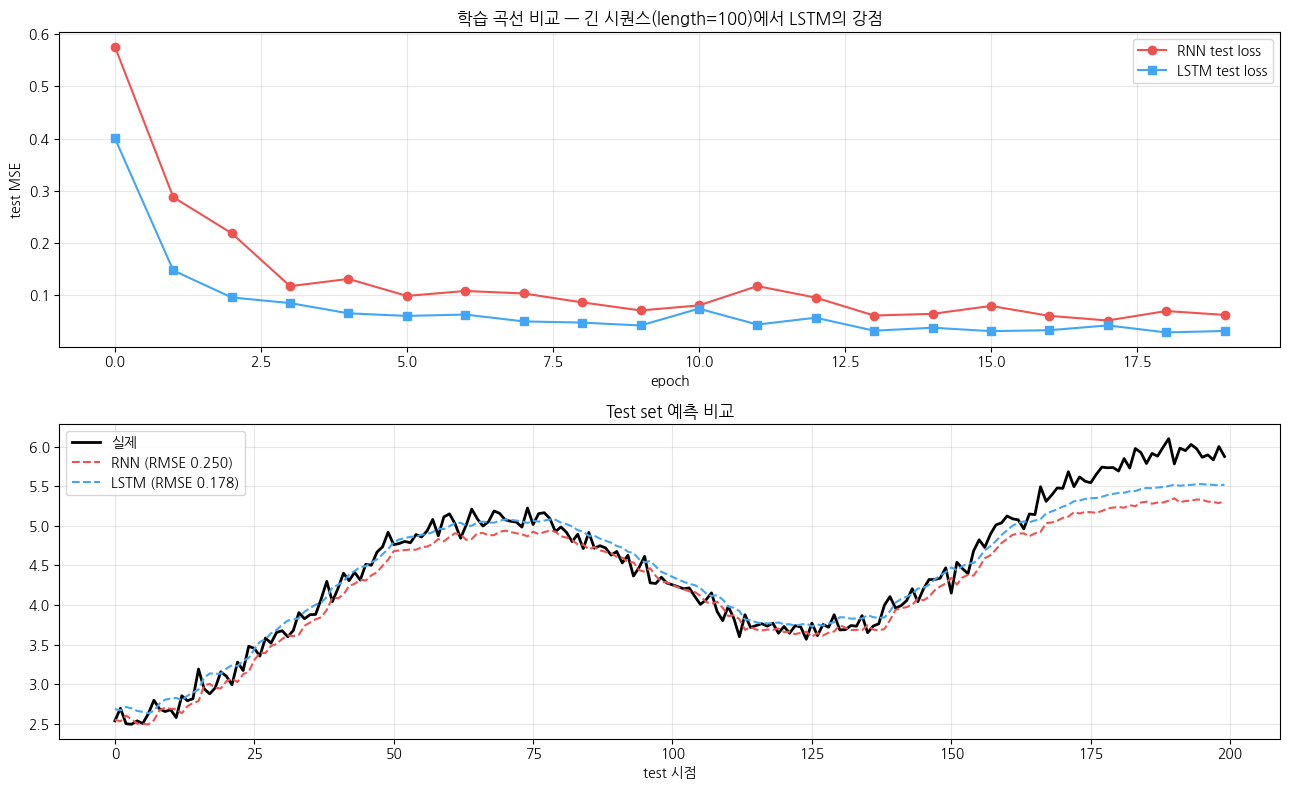


🎉 LSTM이 RNN보다 28.8% 더 정확!
   긴 시퀀스(length=100)에서 LSTM의 강점을 직접 확인했습니다.


In [11]:
# 🧪 미션 2 검증

comparison = compare_models(rnn_model, lstm_model, X_test_t, y_test_t)

print("=" * 60)
print(f"{'메트릭':<20}{'RNN':>15}{'LSTM':>15}")
print("=" * 60)
for metric in ["rmse", "mae", "accuracy_0.2"]:
    rnn_val = comparison["rnn"][metric]
    lstm_val = comparison["lstm"][metric]
    better = "✅" if (lstm_val < rnn_val if metric != "accuracy_0.2" else lstm_val > rnn_val) else "  "
    print(f"  {metric:<18}{rnn_val:>15.4f}{lstm_val:>15.4f}  {better}")
print("=" * 60)
print(f"  LSTM 개선율: {comparison['lstm_improvement_%']:.1f}% (RMSE 기준)")

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

y_true = y_test_t.cpu().numpy().flatten()

# 위: 학습 곡선
axes[0].plot(rnn_test, "o-", label="RNN test loss", color="#ef5350")
axes[0].plot(lstm_test, "s-", label="LSTM test loss", color="#42a5f5")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("test MSE")
axes[0].set_title("학습 곡선 비교 — 긴 시퀀스(length=100)에서 LSTM의 강점")
axes[0].legend(); axes[0].grid(alpha=0.3)

# 아래: 예측 비교 (test set 일부)
n_show = 200
axes[1].plot(y_true[:n_show], label="실제", color="black", lw=2)
axes[1].plot(comparison["rnn"]["pred"][:n_show],  label=f"RNN (RMSE {comparison['rnn']['rmse']:.3f})",
             color="#ef5350", ls="--", lw=1.5)
axes[1].plot(comparison["lstm"]["pred"][:n_show], label=f"LSTM (RMSE {comparison['lstm']['rmse']:.3f})",
             color="#42a5f5", ls="--", lw=1.5)
axes[1].set_xlabel("test 시점"); axes[1].set_title("Test set 예측 비교")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

if comparison["lstm"]["rmse"] < comparison["rnn"]["rmse"]:
    print(f"\n🎉 LSTM이 RNN보다 {comparison['lstm_improvement_%']:.1f}% 더 정확!")
    print("   긴 시퀀스(length=100)에서 LSTM의 강점을 직접 확인했습니다.")
else:
    print(f"\n⚠️ 이번엔 RNN이 더 좋게 나왔어요. 더 긴 시퀀스/더 많은 epoch 필요할 수 있음.")

---
# 7️⃣ 💪 도전 과제

## 도전 1: GRU와 비교

GRU는 LSTM의 **간단 버전** — 게이트가 2개뿐(update, reset). 비슷한 성능에 더 빠름.

```python
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, h = self.gru(x)
        return self.fc(out[:, -1, :])

gru_model = GRUModel(hidden_size=32).to(device)
gru_train, gru_test = train_model(gru_model, X_train_t, y_train_t, X_test_t, y_test_t)
print(f"GRU: train={gru_train[-1]:.4f}, test={gru_test[-1]:.4f}")
```

## 도전 2: 양방향(Bidirectional) LSTM

문장 분석에서 자주 쓰임 — 시퀀스를 앞→뒤 + 뒤→앞 동시에 보기.

```python
nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional=True)
# 출력 차원: hidden_size × 2 (양방향)
```

## 도전 3: 다층(Stacked) LSTM

```python
nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True)
# 더 복잡한 패턴 학습 가능, 학습 시간 ↑
```

## 도전 4: Dropout 추가

```python
nn.LSTM(input_size, hidden_size, num_layers=2, batch_first=True, dropout=0.2)
# 과적합 방지 (num_layers ≥ 2 일 때만 동작)
```

---

# 🎓 정리

## 한 줄 요약

> **"3개의 게이트로 정보 흐름을 제어해서, 중요한 건 오래 기억하는 RNN — LSTM."**

## 오늘 만진 것들

| 무엇을 | 비유 |
|---|---|
| **Cell state** | 화이트보드 (장기 기억) |
| **Hidden state** | 발표 내용 (단기 기억) |
| **Forget gate** | 옛 정보 지울 비율 |
| **Input gate** | 새 정보 받을 비율 |
| **Output gate** | 발표할 비율 |
| **gate = sigmoid (0~1)** | "얼마나 통과시킬까" |
| **value = tanh (-1~1)** | "값 자체" |

## LSTM의 5개 수식 (외워두면 좋음)

```
f_t = sigmoid(W_f · [h, x] + b_f)        ← 옛 거 유지 비율
i_t = sigmoid(W_i · [h, x] + b_i)        ← 새 거 받을 비율
g_t = tanh   (W_g · [h, x] + b_g)        ← 후보 새 정보
C_t = f_t · C_{t-1} + i_t · g_t          ← 새 cell state
h_t = sigmoid(W_o · [h, x] + b_o) · tanh(C_t)  ← 새 hidden
```

## 다음 단계

| 모델 | 한계 → 개선 |
|---|---|
| RNN → **LSTM** ✅ | vanishing gradient 해결 |
| LSTM → **seq2seq** | 입력/출력 길이 다른 task (번역) |
| seq2seq → **Attention** | 긴 입력의 정보 손실 해결 |
| Attention → **Transformer** | 순차 처리 자체를 제거! |

다음 노트북 **seq2seq** 에서는 LSTM을 두 개 (encoder + decoder) 묶어서
한국어 → 아라비아 숫자 변환 같은 **번역 task** 를 해봅니다!

## 추천 자료

- **Christopher Olah's blog** — *Understanding LSTM Networks* (LSTM 그림 설명의 명작)
- **Andrej Karpathy** — *The Unreasonable Effectiveness of Recurrent Neural Networks*
- **PyTorch 공식** — `nn.LSTM` documentation

---

> 🎉 **수고하셨습니다!** RNN의 한계를 직접 경험하고, LSTM이 어떻게 해결했는지 코드로 확인했습니다.
